In [1]:
import lightgbm as lgb
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_squared_error, confusion_matrix, roc_curve, auc
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from optuna.integration import LightGBMPruningCallback
import joblib
import warnings

warnings.filterwarnings('ignore')

/home/sami/Documents/Dev_IA/BriefAPI/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Charger les données
data = pd.read_parquet('SBAnational_ML_Dorothee.parquet')

In [3]:
data.head(3)

,Bank,GrAppv,Term,State,ApprovalYear,NAICS_Sectors,New,Franchise,NoEmp,CreateJob,RetainedJob,RevLineCr,LowDoc,Rural,Crisis,PIF
0,FIFTH THIRD BANK,60000,84,IN,1997,45,1,0,4,0,0,0,1,NaN,0,1
1,1ST SOURCE BANK,40000,60,IN,1997,72,1,0,2,0,0,0,1,NaN,0,1
2,GRANT COUNTY STATE BANK,287000,180,IN,1997,62,0,0,7,0,0,0,0,NaN,0,1


In [4]:
dtype_dict = {
    "GrAppv": "float32",
    "Term": "float32",
    "State": "category",
    "NAICS_Sectors": "category",
    "New": "category",
    "Franchise": "category",
    "NoEmp": "float32",
    "RevLineCr": "category",
    "LowDoc": "category",
    "Rural": "category",
    "PIF": "category"
}

data = data.astype(dtype_dict)

In [5]:
data.drop(columns=['Bank', 'ApprovalYear', 'CreateJob', 'RetainedJob', 'Crisis'], inplace=True)

In [6]:
data

,GrAppv,Term,State,NAICS_Sectors,New,Franchise,NoEmp,RevLineCr,LowDoc,Rural,PIF
0,60000.0,84.0,IN,45,1,0,4.0,0,1,NaN,1
1,40000.0,60.0,IN,72,1,0,2.0,0,1,NaN,1
2,287000.0,180.0,IN,62,0,0,7.0,0,0,NaN,1
3,35000.0,60.0,OK,NaN,0,0,2.0,0,1,NaN,1
4,229000.0,240.0,FL,NaN,0,0,14.0,0,0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...
899159,70000.0,60.0,OH,45,0,0,6.0,NaN,0,NaN,1
899160,85000.0,60.0,OH,45,0,0,6.0,1,0,NaN,1
899161,300000.0,108.0,CA,33,0,0,26.0,0,0,NaN,1
899162,75000.0,60.0,HI,NaN,0,0,6.0,0,1,NaN,0


In [7]:
category_columns = ['State', 'NAICS_Sectors', 'New', 'Franchise', 'RevLineCr', 'LowDoc', 'Rural']
numeric_columns = ['Term', 'GrAppv', 'NoEmp']


In [8]:
# Séparer les caractéristiques et la cible
X = data.drop('PIF', axis=1)  # Remplacez 'PIF' par le nom de votre colonne cible
y = data['PIF']

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [9]:
# Définir le prétraitement pour chaque type de variable
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('encoder', OneHotEncoder(handle_unknown='ignore'))  # Encodage des variables catégorielles
        ]), category_columns)
    ],
    remainder='passthrough')

# Définir le modèle LightGBM
lgbm_model = lgb.LGBMClassifier(objective='binary', metric='auc', boosting_type='gbdt')

# Créer la pipeline complète avec prétraitement et modèle
pipeline = Pipeline([
    ('preprocessor', preprocessor),  # Prétraitement des données
    ('lgbm', lgbm_model)             # Modèle LightGBM
])

# Fonction pour optimiser les hyperparamètres via Optuna
def objective(trial):
    param = {
        'lgbm__objective': 'binary',  # Classification binaire
        'lgbm__metric': 'auc',        # Utilisation de l'AUC comme métrique
        'lgbm__boosting_type': 'gbdt', # Type de boosting (Gradient Boosting Decision Tree)
        'lgbm__lambda_l1': trial.suggest_loguniform('lambda_l1', 1e-8, 10.0),
        'lgbm__lambda_l2': trial.suggest_loguniform('lambda_l2', 1e-8, 10.0),
        'lgbm__num_leaves': trial.suggest_int('num_leaves', 10, 100),
        'lgbm__learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.1),
        'lgbm__feature_fraction': trial.suggest_uniform('feature_fraction', 0.4, 1.0),
        'lgbm__bagging_fraction': trial.suggest_uniform('bagging_fraction', 0.4, 1.0),
        'lgbm__bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'lgbm__min_child_samples': trial.suggest_int('min_child_samples', 5, 100)
    }

    pipeline.set_params(**param)
    
    # Validation croisée avec scores AUC
    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='roc_auc')
    return scores.mean()

# Lancer l'optimisation des hyperparamètres avec Optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50, timeout=600)


[I 2025-02-24 14:13:07,770] A new study created in memory with name: no-name-4872e052-6134-4194-bccd-94f9f50768d5


[LightGBM] [Warning] feature_fraction is set=0.6784365966923007, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6784365966923007
[LightGBM] [Warning] lambda_l2 is set=4.325269263755782e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.325269263755782e-07
[LightGBM] [Warning] lambda_l1 is set=0.7291485780142692, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.7291485780142692
[LightGBM] [Warning] bagging_fraction is set=0.41880182456772447, subsample=1.0 will be ignored. Current value: bagging_fraction=0.41880182456772447
[LightGBM] [Warning] bagging_freq is set=6, subsample_freq=0 will be ignored. Current value: bagging_freq=6
[LightGBM] [Warning] feature_fraction is set=0.6784365966923007, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6784365966923007
[LightGBM] [Warning] lambda_l2 is set=4.325269263755782e-07, reg_lambda=0.0 will be ignored. Current value: lambda_l2=4.325269263755782e-07
[LightGBM] [Warning] l

[I 2025-02-24 14:13:22,857] Trial 0 finished with value: 0.9604444878614767 and parameters: {'lambda_l1': 0.7291485780142692, 'lambda_l2': 4.325269263755782e-07, 'num_leaves': 80, 'learning_rate': 0.02718934011044296, 'feature_fraction': 0.6784365966923007, 'bagging_fraction': 0.41880182456772447, 'bagging_freq': 6, 'min_child_samples': 39}. Best is trial 0 with value: 0.9604444878614767.


[LightGBM] [Warning] feature_fraction is set=0.4858774736759915, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4858774736759915
[LightGBM] [Warning] lambda_l2 is set=8.085924073286636e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.085924073286636e-05
[LightGBM] [Warning] lambda_l1 is set=0.13547383740017532, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.13547383740017532
[LightGBM] [Warning] bagging_fraction is set=0.412337762187463, subsample=1.0 will be ignored. Current value: bagging_fraction=0.412337762187463
[LightGBM] [Warning] bagging_freq is set=7, subsample_freq=0 will be ignored. Current value: bagging_freq=7
[LightGBM] [Warning] feature_fraction is set=0.4858774736759915, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.4858774736759915
[LightGBM] [Warning] lambda_l2 is set=8.085924073286636e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=8.085924073286636e-05
[LightGBM] [Warning] lam

[I 2025-02-24 14:13:34,786] Trial 1 finished with value: 0.9469901460510266 and parameters: {'lambda_l1': 0.13547383740017532, 'lambda_l2': 8.085924073286636e-05, 'num_leaves': 39, 'learning_rate': 0.018821571354618868, 'feature_fraction': 0.4858774736759915, 'bagging_fraction': 0.412337762187463, 'bagging_freq': 7, 'min_child_samples': 16}. Best is trial 0 with value: 0.9604444878614767.


...

[I 2025-02-24 14:22:48,477] Trial 38 finished with value: 0.9655081025041895 and parameters: {'lambda_l1': 3.719609675720767e-08, 'lambda_l2': 0.0008694384602217937, 'num_leaves': 86, 'learning_rate': 0.0514693700682439, 'feature_fraction': 0.960700594647725, 'bagging_fraction': 0.5611858245064585, 'bagging_freq': 6, 'min_child_samples': 72}. Best is trial 18 with value: 0.9675478565729965.


[LightGBM] [Warning] feature_fraction is set=0.6221095868956803, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6221095868956803
[LightGBM] [Warning] lambda_l2 is set=5.3304381073476715e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5.3304381073476715e-06
[LightGBM] [Warning] lambda_l1 is set=1.169757955651629e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=1.169757955651629e-08
[LightGBM] [Warning] bagging_fraction is set=0.6086645418075959, subsample=1.0 will be ignored. Current value: bagging_fraction=0.6086645418075959
[LightGBM] [Warning] bagging_freq is set=3, subsample_freq=0 will be ignored. Current value: bagging_freq=3
[LightGBM] [Warning] feature_fraction is set=0.6221095868956803, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.6221095868956803
[LightGBM] [Warning] lambda_l2 is set=5.3304381073476715e-06, reg_lambda=0.0 will be ignored. Current value: lambda_l2=5.3304381073476715e-06
[LightGBM] [Wa

[I 2025-02-24 14:23:03,698] Trial 39 finished with value: 0.9656789352254679 and parameters: {'lambda_l1': 1.169757955651629e-08, 'lambda_l2': 5.3304381073476715e-06, 'num_leaves': 49, 'learning_rate': 0.09968516753612354, 'feature_fraction': 0.6221095868956803, 'bagging_fraction': 0.6086645418075959, 'bagging_freq': 3, 'min_child_samples': 93}. Best is trial 18 with value: 0.9675478565729965.


[LightGBM] [Warning] feature_fraction is set=0.7683062442514084, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7683062442514084
[LightGBM] [Warning] lambda_l2 is set=0.005550449805687501, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.005550449805687501
[LightGBM] [Warning] lambda_l1 is set=0.39978767375280627, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.39978767375280627
[LightGBM] [Warning] bagging_fraction is set=0.5447738823963799, subsample=1.0 will be ignored. Current value: bagging_fraction=0.5447738823963799
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.7683062442514084, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7683062442514084
[LightGBM] [Warning] lambda_l2 is set=0.005550449805687501, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.005550449805687501
[LightGBM] [Warning] lambd

[I 2025-02-24 14:23:18,566] Trial 40 finished with value: 0.9617621042404029 and parameters: {'lambda_l1': 0.39978767375280627, 'lambda_l2': 0.005550449805687501, 'num_leaves': 94, 'learning_rate': 0.024854040746183984, 'feature_fraction': 0.7683062442514084, 'bagging_fraction': 0.5447738823963799, 'bagging_freq': 4, 'min_child_samples': 49}. Best is trial 18 with value: 0.9675478565729965.


In [10]:
# Affichage des meilleurs hyperparamètres
print("Best hyperparameters: ", study.best_params)

Best hyperparameters:  {'lambda_l1': 6.907842886583572e-08, 'lambda_l2': 1.703188073401647e-05, 'num_leaves': 89, 'learning_rate': 0.09465740365801667, 'feature_fraction': 0.7413758923232424, 'bagging_fraction': 0.4785259788366699, 'bagging_freq': 4, 'min_child_samples': 76}


In [11]:
# Définir les meilleurs hyperparamètres trouvés par Optuna
best_params = study.best_params

# Mettre à jour les noms des paramètres pour qu'ils correspondent à ceux attendus par le pipeline
best_params = {f'lgbm__{key}': value for key, value in best_params.items()}

# Appliquer les meilleurs hyperparamètres au pipeline
pipeline.set_params(**best_params)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['State', 'NAICS_Sectors',
                                                   'New', 'Franchise',
                                                   'RevLineCr', 'LowDoc',
                                                   'Rural'])])),
                ('lgbm',
                 LGBMClassifier(bagging_fraction=0.4785259788366699,
                                bagging_freq=4,
                                feature_fraction=0.7413758923232424,
                                lambda_l1=6.907842886583572e-08,
                                lambda_l2=1.703188073401647e-05,
                                learning_rate=0.09465740365801667, metric='auc',
                                min_child_samples=76, num_leaves=89,
                                objective='binary'))])

In [12]:
pipeline.fit(X_train, y_train)

[LightGBM] [Warning] feature_fraction is set=0.7413758923232424, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7413758923232424
[LightGBM] [Warning] lambda_l2 is set=1.703188073401647e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.703188073401647e-05
[LightGBM] [Warning] lambda_l1 is set=6.907842886583572e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.907842886583572e-08
[LightGBM] [Warning] bagging_fraction is set=0.4785259788366699, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4785259788366699
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.7413758923232424, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7413758923232424
[LightGBM] [Warning] lambda_l2 is set=1.703188073401647e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.703188073401647e-05
[LightGBM] [Warnin

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['State', 'NAICS_Sectors',
                                                   'New', 'Franchise',
                                                   'RevLineCr', 'LowDoc',
                                                   'Rural'])])),
                ('lgbm',
                 LGBMClassifier(bagging_fraction=0.4785259788366699,
                                bagging_freq=4,
                                feature_fraction=0.7413758923232424,
                                lambda_l1=6.907842886583572e-08,
                                lambda_l2=1.703188073401647e-05,
                                learning_rate=0.09465740365801667, metric='auc',
                                min_child_samples=76, num_leaves=89,
                                objective='binary'))])

In [29]:
# Save the pipeline
import pickle

with open("final_model_pipeline.pkl", "wb") as fichier:
    pickle.dump(pipeline, fichier)

In [14]:
# Predictions and evaluation
y_pred_proba = pipeline.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

[LightGBM] [Warning] feature_fraction is set=0.7413758923232424, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7413758923232424
[LightGBM] [Warning] lambda_l2 is set=1.703188073401647e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.703188073401647e-05
[LightGBM] [Warning] lambda_l1 is set=6.907842886583572e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.907842886583572e-08
[LightGBM] [Warning] bagging_fraction is set=0.4785259788366699, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4785259788366699
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4


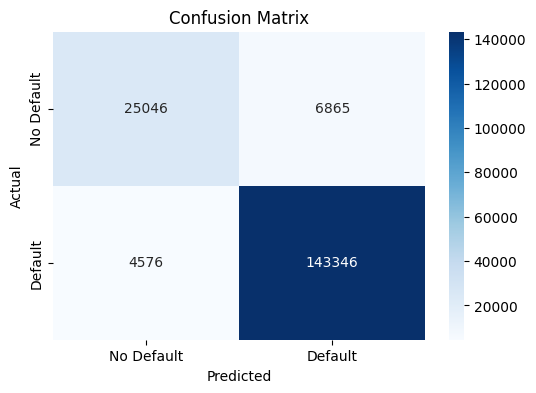

In [15]:
# Confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['No Default', 'Default'], yticklabels=['No Default', 'Default'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

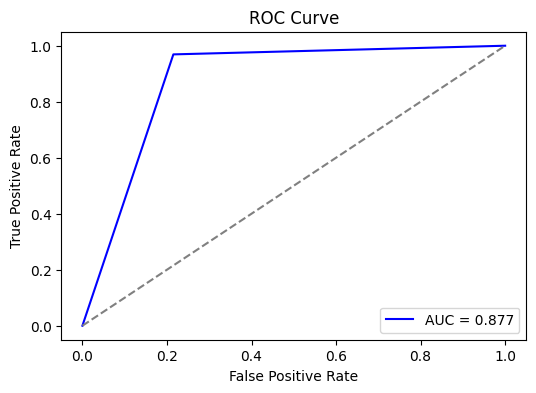

In [16]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

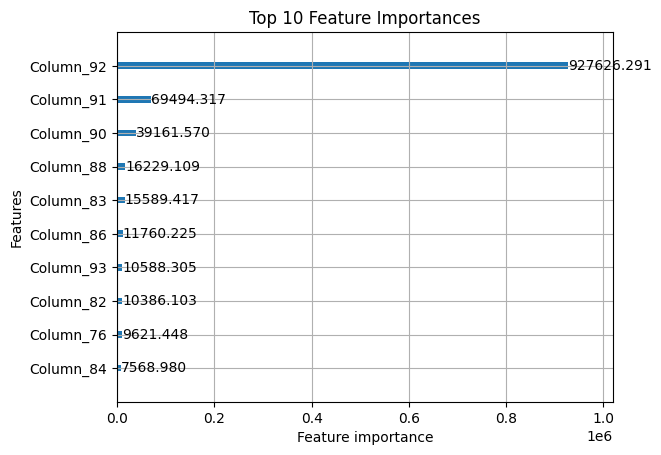

Final Model Accuracy: 0.936


In [17]:
# Feature Importance

lgb.plot_importance(pipeline.named_steps['lgbm'], max_num_features=10, importance_type='gain')
plt.title('Top 10 Feature Importances')
plt.show()

print(f'Final Model Accuracy: {accuracy_score(y_test, y_pred):.3f}')

In [18]:
some_data = data.iloc[:5]
some_data.to_csv('some_data.csv', index=False)

In [20]:
some_data

,GrAppv,Term,State,NAICS_Sectors,New,Franchise,NoEmp,RevLineCr,LowDoc,Rural,PIF
0,60000.0,84.0,IN,45,1,0,4.0,0,1,NaN,1
1,40000.0,60.0,IN,72,1,0,2.0,0,1,NaN,1
2,287000.0,180.0,IN,62,0,0,7.0,0,0,NaN,1
3,35000.0,60.0,OK,NaN,0,0,2.0,0,1,NaN,1
4,229000.0,240.0,FL,NaN,0,0,14.0,0,0,NaN,1


In [21]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 179833 entries, 627637 to 820092
Data columns (total 10 columns):
 #   Column         Non-Null Count   Dtype   
---  ------         --------------   -----   
 0   GrAppv         179833 non-null  float32 
 1   Term           179833 non-null  float32 
 2   State          179833 non-null  category
 3   NAICS_Sectors  139429 non-null  category
 4   New            179608 non-null  category
 5   Franchise      179833 non-null  category
 6   NoEmp          179833 non-null  float32 
 7   RevLineCr      124196 non-null  category
 8   LowDoc         178595 non-null  category
 9   Rural          115183 non-null  category
dtypes: category(7), float32(3)
memory usage: 4.6 MB


In [22]:
predict_antoine = X_test[:1]

In [23]:
predict_antoine

,GrAppv,Term,State,NAICS_Sectors,New,Franchise,NoEmp,RevLineCr,LowDoc,Rural
627637,50000.0,36.0,UT,23,0,0,3.0,1,0,0


In [25]:
pipeline.predict(predict_antoine)

[LightGBM] [Warning] feature_fraction is set=0.7413758923232424, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.7413758923232424
[LightGBM] [Warning] lambda_l2 is set=1.703188073401647e-05, reg_lambda=0.0 will be ignored. Current value: lambda_l2=1.703188073401647e-05
[LightGBM] [Warning] lambda_l1 is set=6.907842886583572e-08, reg_alpha=0.0 will be ignored. Current value: lambda_l1=6.907842886583572e-08
[LightGBM] [Warning] bagging_fraction is set=0.4785259788366699, subsample=1.0 will be ignored. Current value: bagging_fraction=0.4785259788366699
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4


array([1])